# 3D-CNN Exercise Recognition Training

This notebook implements a 3D Convolutional Neural Network for recognizing exercises from skeleton pose data and training loop. The best model is saved to `output/` directory.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 1. Configuration

In [3]:
# Paths
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
SKELETON_DIR = DATA_DIR / "skeleton" / "yolo_pose_csv"
LABEL_DIR = DATA_DIR / "label"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
# Model hyperparameters
CONFIG = {
    # Data parameters
    'sequence_length': 64,      # Number of frames per sample (temporal dimension)
    'stride': 32,               # Stride for sliding window
    'num_keypoints': 17,        # YOLO pose keypoints
    'num_coords': 3,            # x, y, z coordinates

    # Training parameters
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 50,
    'patience': 10,             # Early stopping patience

    # Model parameters
    'hidden_channels': [32, 64, 128],
    'dropout': 0.3,

    # Data split
    'test_size': 0.2,
    'val_size': 0.1,
}

## 2. Data Loading Functions

In [ ]:
def load_skeleton_file(filepath):
    """Load skeleton CSV file and convert to numpy array.
    Returns array of shape (num_frames, num_keypoints, 3)
    """
    df = pd.read_csv(filepath)

    # Get landmark order from first frame
    landmarks_order = df[df['frame_number'] == df['frame_number'].min()]['landmark'].tolist()
    num_keypoints = len(landmarks_order)

    # Get unique frames
    frames = sorted(df['frame_number'].unique())
    num_frames = len(frames)

    # Create array
    skeleton_array = np.zeros((num_frames, num_keypoints, 3), dtype=np.float32)

    for frame_idx, frame_num in enumerate(frames):
        frame_data = df[df['frame_number'] == frame_num]
        for kp_idx, landmark in enumerate(landmarks_order):
            kp_data = frame_data[frame_data['landmark'] == landmark]
            if len(kp_data) > 0:
                skeleton_array[frame_idx, kp_idx, 0] = kp_data['x'].values[0]
                skeleton_array[frame_idx, kp_idx, 1] = kp_data['y'].values[0]
                skeleton_array[frame_idx, kp_idx, 2] = kp_data['z'].values[0]

    return skeleton_array, landmarks_order


def load_label_file(filepath):
    """Load label CSV file.
    Returns array of labels for each frame.
    """
    df = pd.read_csv(filepath, header=None, names=['frame', 'col1', 'label'])
    return df['label'].values


def get_matching_files(skeleton_dir, label_dir):
    """Get list of files that exist in both skeleton and label directories."""
    skeleton_files = set([f.replace('.csv', '') for f in os.listdir(skeleton_dir) if f.endswith('.csv')])
    label_files = set([f.replace('.csv', '') for f in os.listdir(label_dir) if f.endswith('.csv')])
    return sorted(list(skeleton_files.intersection(label_files)))

In [6]:
def create_sequences(skeleton_data, labels, sequence_length, stride, exclude_no_activity=True):
    """Create sequences from skeleton data using sliding window.
    
    Args:
        skeleton_data: Array of shape (num_frames, num_keypoints, 3)
        labels: Array of labels for each frame
        sequence_length: Number of frames per sequence
        stride: Step size for sliding window
        exclude_no_activity: If True, skip sequences with only no-activity labels
    
    Returns:
        sequences: List of arrays, each (sequence_length, num_keypoints, 3)
        sequence_labels: List of labels (majority vote for each sequence)

    """
    sequences = []
    sequence_labels = []

    num_frames = len(skeleton_data)

    for start_idx in range(0, num_frames - sequence_length + 1, stride):
        end_idx = start_idx + sequence_length

        # Get sequence data
        seq_data = skeleton_data[start_idx:end_idx]
        seq_labels = labels[start_idx:end_idx]

        # Get majority label (excluding -1 if there are exercise labels)
        exercise_labels = seq_labels[seq_labels != -1]

        if len(exercise_labels) > 0:
            # Use majority vote among exercise labels
            label_counts = Counter(exercise_labels)
            majority_label = label_counts.most_common(1)[0][0]
        else:
            if exclude_no_activity:
                continue
            majority_label = -1

        sequences.append(seq_data)
        sequence_labels.append(majority_label)

    return sequences, sequence_labels

## 3. Load and Process All Data

In [7]:
# Get matching files
matching_files = get_matching_files(SKELETON_DIR, LABEL_DIR)
print(f"Found {len(matching_files)} matching files")

# Load all data and create sequences
all_sequences = []
all_labels = []

print("\nLoading and processing files...")
for file_name in tqdm(matching_files):
    skeleton_path = SKELETON_DIR / f"{file_name}.csv"
    label_path = LABEL_DIR / f"{file_name}.csv"

    try:
        # Load data
        skeleton_data, _ = load_skeleton_file(skeleton_path)
        labels = load_label_file(label_path)

        # Ensure same length
        min_len = min(len(skeleton_data), len(labels))
        skeleton_data = skeleton_data[:min_len]
        labels = labels[:min_len]

        # Create sequences
        sequences, seq_labels = create_sequences(
            skeleton_data, labels,
            CONFIG['sequence_length'],
            CONFIG['stride'],
            exclude_no_activity=True
        )

        all_sequences.extend(sequences)
        all_labels.extend(seq_labels)

    except Exception as e:
        print(f"Error processing {file_name}: {e}")

print(f"\nTotal sequences created: {len(all_sequences)}")

Found 59 matching files

Loading and processing files...


100%|██████████| 59/59 [50:56<00:00, 51.81s/it]


Total sequences created: 14617


In [8]:
# Convert to numpy arrays
X = np.array(all_sequences, dtype=np.float32)
y = np.array(all_labels, dtype=np.int64)

print(f"X shape: {X.shape}")  # (num_samples, sequence_length, num_keypoints, 3)
print(f"y shape: {y.shape}")

# Create label mapping (remap labels to 0, 1, 2, ...)
unique_labels = sorted(set(y))
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_mapped = np.array([label_to_idx[label] for label in y])
num_classes = len(unique_labels)

print("\nLabel mapping:")
for label, idx in label_to_idx.items():
    count = np.sum(y == label)
    print(f"  {label} -> {idx}: {count} samples")
print(f"\nNumber of classes: {num_classes}")

X shape: (14617, 64, 17, 3)
y shape: (14617,)

Label mapping:
  1 -> 0: 4282 samples
  2 -> 1: 732 samples
  3 -> 2: 700 samples
  4 -> 3: 671 samples
  5 -> 4: 732 samples
  6 -> 5: 651 samples
  7 -> 6: 697 samples
  8 -> 7: 740 samples
  9 -> 8: 653 samples
  10 -> 9: 656 samples
  11 -> 10: 644 samples
  12 -> 11: 694 samples
  13 -> 12: 730 samples
  14 -> 13: 666 samples
  15 -> 14: 720 samples
  16 -> 15: 649 samples

Number of classes: 16


## 4. Data Splitting and Dataset Class

In [9]:
# Split data into train, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_mapped, test_size=CONFIG['test_size'], random_state=42, stratify=y_mapped
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=CONFIG['val_size']/(1-CONFIG['test_size']),
    random_state=42, stratify=y_train_val
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Training samples: 10231
Validation samples: 1462
Test samples: 2924


In [10]:
class SkeletonDataset(Dataset):
    """PyTorch Dataset for skeleton sequences."""

    def __init__(self, sequences, labels, augment=False):
        """Args:
        sequences: numpy array of shape (N, T, K, 3) - T=temporal, K=keypoints
        labels: numpy array of shape (N,)
        augment: whether to apply data augmentation
        """
        self.sequences = sequences
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        # Get data
        x = self.sequences[idx].copy()  # (T, K, 3)
        y = self.labels[idx]

        # Data augmentation
        if self.augment:
            x = self._augment(x)

        # Transpose to (C, T, K) where C=3 (coordinates as channels)
        # This is suitable for 3D convolution: (batch, channels, depth, height, width)
        # Here: (batch, 3, T, K) where we treat keypoints as spatial dimension
        x = x.transpose(2, 0, 1)  # (3, T, K)

        return torch.FloatTensor(x), torch.LongTensor([y]).squeeze()

    def _augment(self, x):
        """Apply data augmentation to skeleton sequence."""
        # Random horizontal flip (mirror skeleton)
        if np.random.random() > 0.5:
            x[:, :, 0] = 1 - x[:, :, 0]  # Flip x coordinate
            # Swap left/right keypoints
            # YOLO order: NOSE, L_EYE, R_EYE, L_EAR, R_EAR, L_SHOULDER, R_SHOULDER,
            #             L_ELBOW, R_ELBOW, L_WRIST, R_WRIST, L_HIP, R_HIP,
            #             L_KNEE, R_KNEE, L_ANKLE, R_ANKLE
            swap_pairs = [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12), (13, 14), (15, 16)]
            for i, j in swap_pairs:
                x[:, i, :], x[:, j, :] = x[:, j, :].copy(), x[:, i, :].copy()

        # Random noise
        if np.random.random() > 0.5:
            noise = np.random.normal(0, 0.01, x.shape).astype(np.float32)
            x = x + noise

        # Random scaling
        if np.random.random() > 0.5:
            scale = np.random.uniform(0.9, 1.1)
            x = x * scale

        return x

In [11]:
# Create datasets and dataloaders
train_dataset = SkeletonDataset(X_train, y_train, augment=True)
val_dataset = SkeletonDataset(X_val, y_val, augment=False)
test_dataset = SkeletonDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

# Verify data shape
sample_x, sample_y = next(iter(train_loader))
print(f"Sample batch X shape: {sample_x.shape}")  # Expected: (batch_size, 3, T, K)
print(f"Sample batch y shape: {sample_y.shape}")

Sample batch X shape: torch.Size([32, 3, 64, 17])
Sample batch y shape: torch.Size([32])


## 5. 3D-CNN Model Architecture

In [12]:
class Action3DCNN(nn.Module):
    """3D-CNN for skeleton-based action recognition.

    Input shape: (batch, 3, T, K) where:
        - 3: coordinates (x, y, z) as channels
        - T: temporal dimension (sequence_length)
        - K: keypoints (17)

    We treat this as a 2D problem with 3 channels (like RGB image)
    where the spatial dimensions are (T, K) - temporal x keypoints.
    This avoids issues with 3D pooling making dimensions too small.
    """

    def __init__(self, num_classes, sequence_length=64, num_keypoints=17,
                 hidden_channels=[32, 64, 128], dropout=0.3):
        super().__init__()

        self.num_classes = num_classes
        self.sequence_length = sequence_length
        self.num_keypoints = num_keypoints

        # Use 2D convolutions treating (T, K) as spatial dimensions
        # Input: (batch, 3, T, K) - 3 channels (x, y, z), T=height, K=width

        self.conv_layers = nn.ModuleList()

        in_ch = 3  # x, y, z coordinates as channels
        for out_ch in hidden_channels:
            self.conv_layers.append(
                nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                    nn.MaxPool2d(kernel_size=2, stride=2)
                )
            )
            in_ch = out_ch

        # Calculate flattened size after conv layers
        self._calc_flat_size(sequence_length, num_keypoints)

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(self.flat_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

        # For GradCAM - store intermediate features
        self.gradients = None
        self.activations = None

    def _calc_flat_size(self, T, K):
        """Calculate size after all conv layers."""
        h, w = T, K
        for _ in self.conv_layers:
            h = h // 2
            w = max(w // 2, 1)
        self.flat_size = self.conv_layers[-1][0].out_channels * h * w

    def activations_hook(self, grad):
        """Hook for gradients."""
        self.gradients = grad

    def forward(self, x):
        # Input x: (batch, 3, T, K) - already in correct format for Conv2d

        # Apply conv layers
        for i, conv_block in enumerate(self.conv_layers):
            x = conv_block(x)

            # Store activations from last conv layer for GradCAM
            if i == len(self.conv_layers) - 1:
                self.activations = x
                if x.requires_grad:
                    x.register_hook(self.activations_hook)

        # Flatten and classify
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self):
        return self.activations

In [13]:
# Create model
model = Action3DCNN(
    num_classes=num_classes,
    sequence_length=CONFIG['sequence_length'],
    num_keypoints=CONFIG['num_keypoints'],
    hidden_channels=CONFIG['hidden_channels'],
    dropout=CONFIG['dropout']
).to(device)

# Print model summary
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Test forward pass
with torch.no_grad():
    test_input = sample_x.to(device)
    test_output = model(test_input)
    print("\nTest forward pass:")
    print(f"  Input shape: {test_input.shape}")
    print(f"  Output shape: {test_output.shape}")

Action3DCNN(
  (conv_layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=

## 6. Training Functions

In [14]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    """Evaluate model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

## 7. Training Loop

In [15]:
# Calculate class weights for imbalanced data
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.FloatTensor(class_weights).to(device)

print("Class weights:", class_weights)

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = Adam(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-4)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Class weights: tensor([0.1694, 0.9917, 1.0362, 1.0803, 0.9897, 1.1134, 1.0404, 0.9802, 1.1110,
        1.1062, 1.1258, 1.0469, 0.9936, 1.0895, 1.0074, 1.1183],
       device='cuda:0')


In [16]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_model_state = None
patience_counter = 0

print("Starting training...")
print("=" * 70)

for epoch in range(CONFIG['num_epochs']):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print progress
    print(f"Epoch [{epoch+1}/{CONFIG['num_epochs']}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"  -> New best model. Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= CONFIG['patience']:
        print(f"\nEarly stopping after {epoch+1} epochs")
        break

print("=" * 70)
print(f"Training completed! Best validation accuracy: {best_val_acc:.2f}%")

Starting training...
Epoch [1/50] Train Loss: 2.0271, Train Acc: 30.01% | Val Loss: 1.4555, Val Acc: 50.48%
  -> New best model. Val Acc: 50.48%
Epoch [2/50] Train Loss: 0.9597, Train Acc: 63.64% | Val Loss: 0.6292, Val Acc: 76.61%
  -> New best model. Val Acc: 76.61%
Epoch [3/50] Train Loss: 0.7408, Train Acc: 73.38% | Val Loss: 0.5219, Val Acc: 81.81%
  -> New best model. Val Acc: 81.81%
Epoch [4/50] Train Loss: 0.6230, Train Acc: 78.10% | Val Loss: 0.4336, Val Acc: 82.76%
  -> New best model. Val Acc: 82.76%
Epoch [5/50] Train Loss: 0.5933, Train Acc: 79.68% | Val Loss: 0.3990, Val Acc: 85.64%
  -> New best model. Val Acc: 85.64%
Epoch [6/50] Train Loss: 0.5471, Train Acc: 81.72% | Val Loss: 0.3985, Val Acc: 85.70%
  -> New best model. Val Acc: 85.70%
Epoch [7/50] Train Loss: 0.4791, Train Acc: 83.93% | Val Loss: 0.3256, Val Acc: 89.40%
  -> New best model. Val Acc: 89.40%
Epoch [8/50] Train Loss: 0.4829, Train Acc: 83.88% | Val Loss: 0.3530, Val Acc: 86.80%
Epoch [9/50] Train Loss:

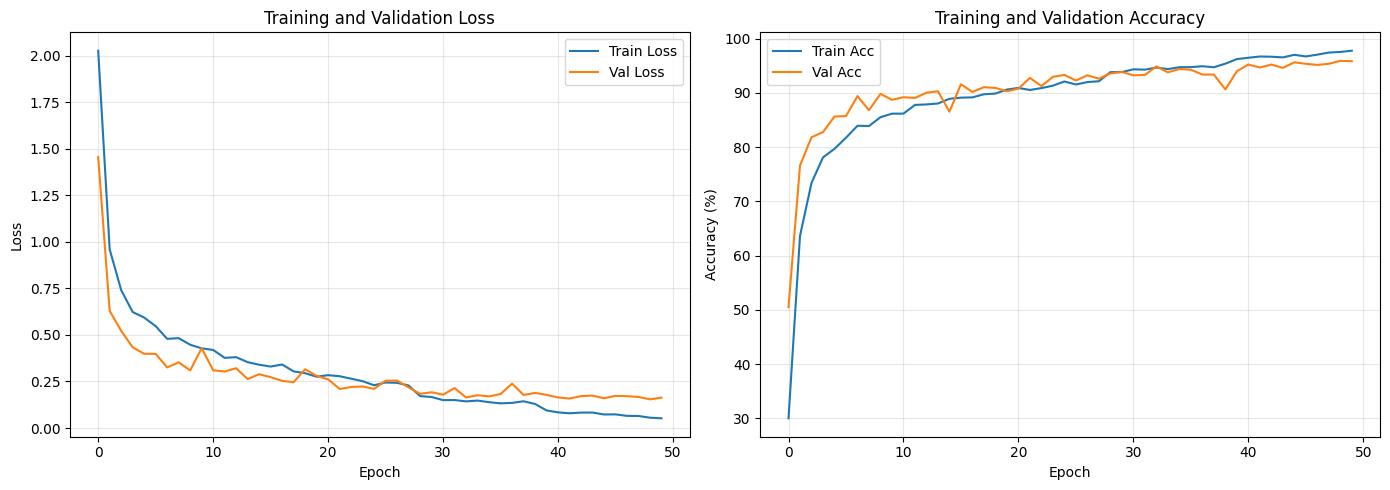

In [17]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150)
plt.show()

## 8. Model Evaluation

In [18]:
# Load best model
model.load_state_dict(best_model_state)

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification report
class_names = [f"Exercise {idx_to_label[i]}" for i in range(num_classes)]
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

Test Loss: 0.2266
Test Accuracy: 94.53%

Classification Report:
              precision    recall  f1-score   support

  Exercise 1       0.98      0.95      0.97       857
  Exercise 2       0.98      0.97      0.98       147
  Exercise 3       0.95      0.94      0.94       140
  Exercise 4       0.95      0.95      0.95       134
  Exercise 5       0.86      0.90      0.88       146
  Exercise 6       0.89      0.97      0.93       130
  Exercise 7       0.99      0.98      0.99       139
  Exercise 8       0.94      0.88      0.91       148
  Exercise 9       0.90      0.92      0.91       131
 Exercise 10       0.92      0.94      0.93       131
 Exercise 11       0.97      0.98      0.97       129
 Exercise 12       0.90      1.00      0.95       139
 Exercise 13       0.98      0.92      0.95       146
 Exercise 14       0.90      0.95      0.92       133
 Exercise 15       0.86      0.89      0.88       144
 Exercise 16       0.99      0.98      0.99       130

    accuracy    

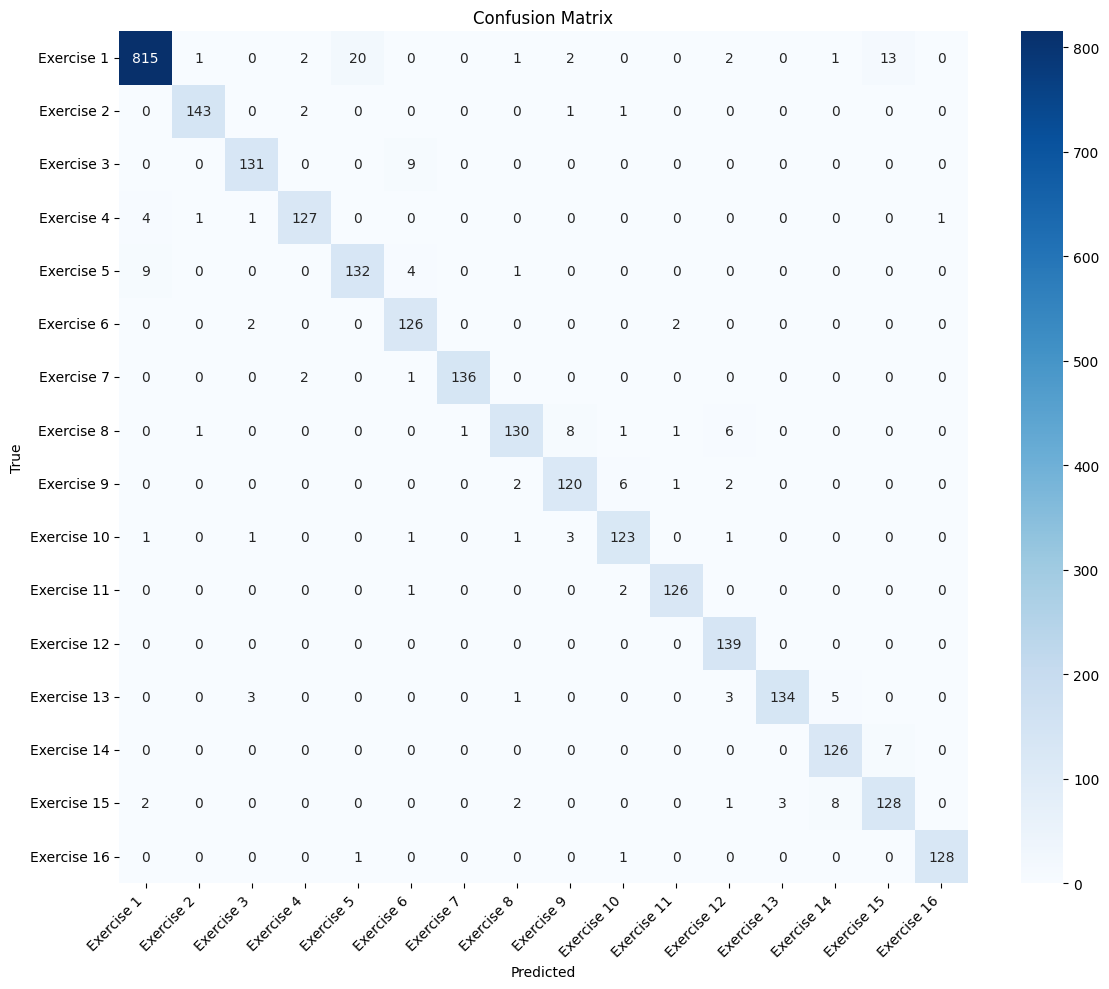

In [19]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 9. Save Model

In [20]:
# Save model and metadata
model_save_path = OUTPUT_DIR / 'action_3dcnn_model.pth'

# Save complete checkpoint
checkpoint = {
    'model_state_dict': best_model_state,
    'config': CONFIG,
    'num_classes': num_classes,
    'label_to_idx': label_to_idx,
    'idx_to_label': idx_to_label,
    'class_names': class_names,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'history': history
}

torch.save(checkpoint, model_save_path)
print(f"Model saved to: {model_save_path}")

# Also save just the model weights for easier loading
weights_save_path = OUTPUT_DIR / 'action_3dcnn_weights.pth'
torch.save(best_model_state, weights_save_path)
print(f"Weights saved to: {weights_save_path}")

Model saved to: C:\Users\looxx\Desktop\studia\widzenie_komputerowe\3D-Conv-Action-GradCAM\output\action_3dcnn_model.pth
Weights saved to: C:\Users\looxx\Desktop\studia\widzenie_komputerowe\3D-Conv-Action-GradCAM\output\action_3dcnn_weights.pth
